In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [3]:
X, y = make_classification(
    n_samples=2000,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    weights=[0.95, 0.05],  
    random_state=42
)

print("Proporcje klas:", np.bincount(y))

Proporcje klas: [1890  110]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
y_pred = model.predict(X_test)

In [7]:
y_proba = model.predict_proba(X_test)[:, 1]

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.975
Precision: 0.95
Recall: 0.5757575757575758
F1: 0.7169811320754716
AUC: 0.9377371599593822

Confusion matrix:
[[566   1]
 [ 14  19]]


In [9]:
threshold = 0.3
y_pred_new = (y_proba >= threshold).astype(int)

print("=== Threshold 0.3 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_new))

=== Threshold 0.3 ===
Accuracy: 0.9733333333333334
Precision: 0.84
Recall: 0.6363636363636364
F1: 0.7241379310344828

Confusion matrix:
[[563   4]
 [ 12  21]]


In [10]:
threshold = 0.15
y_pred_new = (y_proba >= threshold).astype(int)

print("=== Threshold 0.15 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))

=== Threshold 0.15 ===
Accuracy: 0.95
Precision: 0.5365853658536586
Recall: 0.6666666666666666
F1: 0.5945945945945946


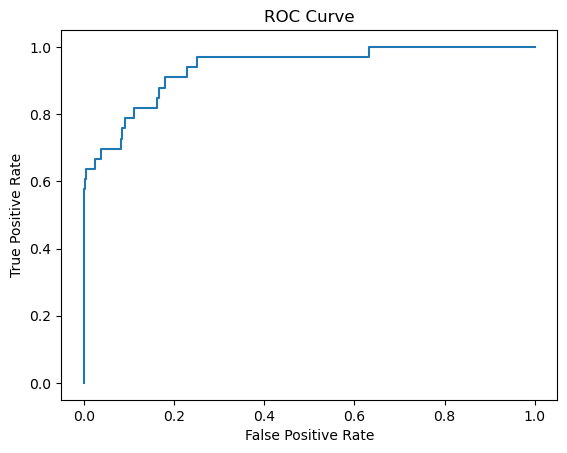

In [11]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [12]:
model_weighted = LogisticRegression(class_weight='balanced')
model_weighted.fit(X_train, y_train)

y_proba_w = model_weighted.predict_proba(X_test)[:, 1]
y_pred_w = model_weighted.predict(X_test)

print("=== Weighted model (threshold=0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_w))
print("Precision:", precision_score(y_test, y_pred_w))
print("Recall:", recall_score(y_test, y_pred_w))
print("F1:", f1_score(y_test, y_pred_w))
print("AUC:", roc_auc_score(y_test, y_proba_w))

=== Weighted model (threshold=0.5) ===
Accuracy: 0.865
Precision: 0.27358490566037735
Recall: 0.8787878787878788
F1: 0.4172661870503597
AUC: 0.9442573887018331
